In [3]:
import os
import time
from tqdm import tqdm

import numpy as np
import pandas as pd
import torchvision.transforms as transforms
import torchvision
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from utils.utils_purify import *

try: 
    import torch_xla.core.xla_model as xm
    import torch_xla.distributed.xla_multiprocessing as xmp
except: pass


from utils.EBM_models import create_ebm
from utils.Diff_models import create_diffusion_model

os.environ['XRT_TPU_CONFIG'] = 'localservice;0;localhost:51011'
device = xm.xla_device() if 'xm' in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
# Load EBM and Diffusion models
ebm_model = create_ebm('EBM',32)
ebm_model.load_state_dict(torch.load(os.path.join('/home/sunaybhat/data','PureGen_Models','EBM','cinic10_imagenet_ep120_nf32.pt'),map_location=torch.device('cpu')))

diff_model = create_diffusion_model('UNET_SMALL',3, 3, time_emb_dim=64, num_res_blocks=2, nf=64)
diff_model.load_state_dict(torch.load(os.path.join('/home/sunaybhat/data','PureGen_Models','UNET_SMALL','cifar10_ep60_nf64_EBM[cinic10_imagenet_ep120_nf32].pt'),map_location=torch.device('cpu')))

# To device
ebm_model = ebm_model.to(device)
diff_model = diff_model.to(device)

In [9]:
train_data = torchvision.datasets.CIFAR10(root='/home/sunaybhat/data', train=True, download=True, transform=transforms.Compose([transforms.ToTensor()]))
data = next(iter(DataLoader(train_data, batch_size=16)))[0].to(device)

Files already downloaded and verified


In [22]:
mcmc_steps = 100

data_purified = ebm_purify(ebm_model,data,mcmc_steps,langevin_temp=1e-4)

t_s = torch.ones(data_purified.shape[0]) * mcmc_steps
diff_residual = diff_model(data_purified, timestep_to_sinusoial_tensor(t_s,64).to(device))

diff_fixed = data_purified + diff_residual

Text(0.5, 1.0, 'Diffusion Fixed')

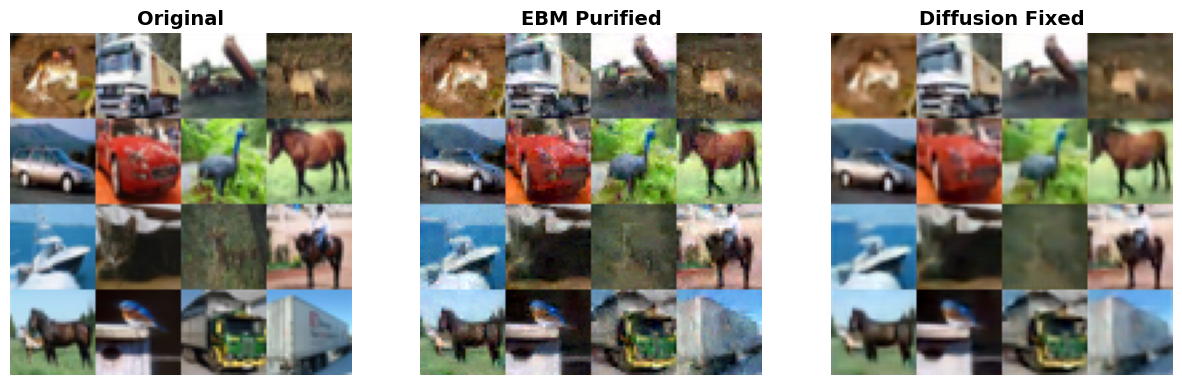

In [23]:
# Plot 1x3 of original, purified and fixed
import matplotlib.pyplot as plt

plot_images_data = np.block([[data[i*4+j,:,:,:].detach().cpu().numpy() for j in range(4)] for i in range(4)])
plot_images_purified = np.block([[data_purified[i*4+j,:,:,:].detach().cpu().numpy() for j in range(4)] for i in range(4)])
plot_images_fixed = np.block([[diff_fixed[i*4+j,:,:,:].detach().cpu().numpy() for j in range(4)] for i in range(4)])      


fig, axs = plt.subplots(1,3,figsize=(15,5))

axs[0].imshow(plot_images_data.transpose(1, 2, 0))
axs[0].axis('off')
axs[0].set_title('Original', fontsize=14, fontweight='bold')

axs[1].imshow(plot_images_purified.transpose(1, 2, 0))
axs[1].axis('off')
axs[1].set_title('EBM Purified', fontsize=14, fontweight='bold')

axs[2].imshow(plot_images_fixed.transpose(1, 2, 0))
axs[2].axis('off')
axs[2].set_title('Diffusion Fixed', fontsize=14, fontweight='bold')